<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/tomada2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Configurações
API_KEY = "0XRTPWUZLEA2ZAG0"
SYMBOL = "AAPL"
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}"

# Extração
response = requests.get(url)
data = response.json()

# Conversão e limpeza inicial
df = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
df.columns = ["open", "high", "low", "close", "volume"]
df = df.astype(float)
df.index = pd.to_datetime(df.index)
df.sort_index(ascending=True, inplace=True)

print("Extração concluída com sucesso.")
df.head()

Extração concluída com sucesso.


,open,high,low,close,volume
2025-12-10,277.750,279.75,276.44,278.78,33038318.0
2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2025-12-12,277.900,279.22,276.82,278.28,39532887.0
2025-12-15,280.150,280.15,272.84,274.11,50409078.0
2025-12-16,272.820,275.50,271.79,274.61,37648628.0


In [72]:
# Verificação de nulos
print("Nulos encontrados:\n", df.isnull().sum())

# Engenharia de Preditores (X): Criando variáveis defasadas (Shift)
# Calculamos a amplitude bruta para usar como base
df['amplitude_raw'] = df['high'] - df['low']

# Usamos a amplitude e o volume de 'ontem' para prever 'hoje'
df['X_amplitude'] = df['amplitude_raw'].shift(1)
df['X_volume'] = df['volume'].shift(1)

# Removemos a primeira linha (NaN devido ao shift) para normalizar
df_clean = df.dropna().copy()

# Aplicação do StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[['X_amplitude', 'X_volume']])

# DataFrame de Preditores X
X = pd.DataFrame(X_scaled, columns=['amplitude_norm', 'volume_norm'], index=df_clean.index)

Nulos encontrados:
 open      0
high      0
low       0
close     0
volume    0
dtype: int64


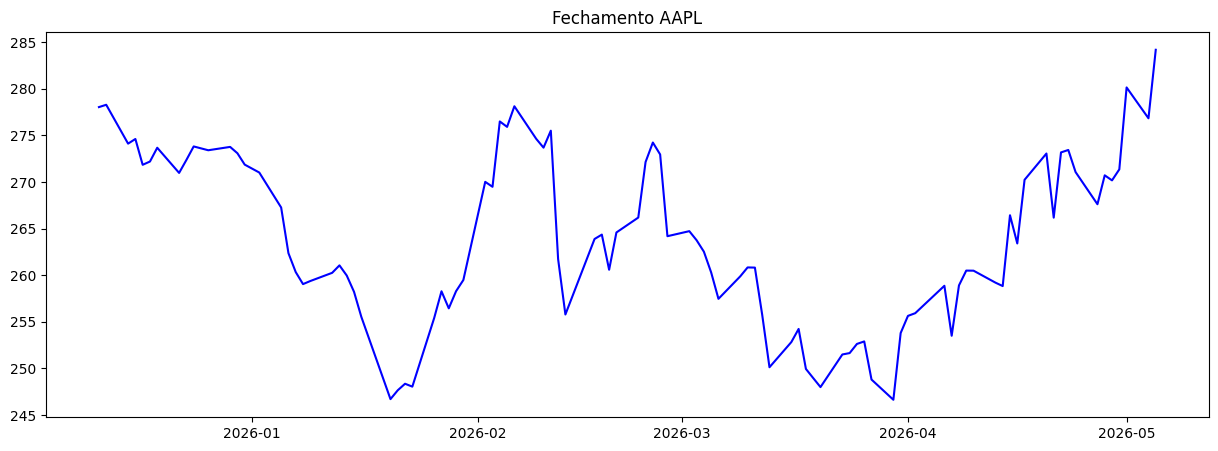

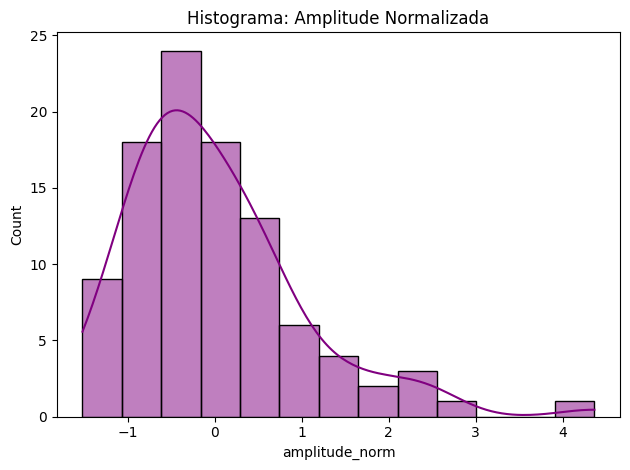

In [73]:
plt.figure(figsize=(15, 5))

# Gráfico de Fechamento
plt.plot(df_clean['close'], color='blue')
plt.title('Fechamento AAPL')
plt.show()

# DESAFIO: Histograma da Amplitude Normalizada
sns.histplot(X['amplitude_norm'], kde=True, color='purple')
plt.title('Histograma: Amplitude Normalizada')

plt.tight_layout()
plt.show()

In [74]:
# Média móvel de 100 dias com SHIFT para não olhar o dado de hoje
df_clean['media_100'] = df_clean['amplitude_raw'].shift(1).rolling(window=100, min_periods=1).mean()

# Regra: Alta_Volatilidade se a amplitude de HOJE superar a média móvel de ONTEM
df_clean['Y'] = (df_clean['amplitude_raw'] > df_clean['media_100']).astype(int)

# Limpeza final: remove o novo NaN criado pelo shift da média
df_final = df_clean.dropna().copy()

print("Distribuição das classes (0: Baixa, 1: Alta):")
print(df_final['Y'].value_counts())

Distribuição das classes (0: Baixa, 1: Alta):
Y
0    52
1    46
Name: count, dtype: int64


In [75]:
# Sincronizando os dados finais
y_final = df_final['Y']
X_final = X.loc[df_final.index] # Garante que X e Y tenham as mesmas datas

# Divisão temporal (Treina no passado, testa no futuro)
split_index = int(len(X_final) * 0.8)

X_train = X_final.iloc[:split_index]
X_test = X_final.iloc[split_index:]
y_train = y_final.iloc[:split_index]
y_test = y_final.iloc[split_index:]

# Treinamento
model = GaussianNB()
model.fit(X_train, y_train)

# Avaliação
y_pred = model.predict(X_test)

print(f"Acurácia final: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia final: 60.00%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.60      0.82      0.69        11
           1       0.60      0.33      0.43         9

    accuracy                           0.60        20
   macro avg       0.60      0.58      0.56        20
weighted avg       0.60      0.60      0.57        20

